---
date: "2026-07-20"
date-modified: last-modified
format:
  html:
    toc: true
---

# Chebyshev's Inequality

## 1\. Statement of Chebyshev's Inequality

::: {#thm-chebyshevs-inequality}
## Chebyshev's Inequality
Let $X$ be a [Random Variable](random-variables.ipynb) with finite [Expectation](expectation.ipynb) $\mu = E(X)$ and finite [Variance](variance.ipynb) $\sigma^2 = \text{Var}(X)$. For any real threshold $a > 0$:
$$
\mathbb{P}(|X - \mu| \geq a) \leq \frac{\text{Var}(X)}{a^2}
$$
:::

## 2\. Proof of Chebyshev's Inequality

::: {.callout-tip collapse="true"}
## Proof of Chebyshev's Inequality (via Markov's Inequality)
Notice that the event $|X - \mu| \geq a$ is strictly equivalent to squaring both sides, since $a > 0$ and absolute values are strictly non-negative:
$$
|X - \mu| \geq a \iff (X - \mu)^2 \geq a^2
$$
Because these two algebraic statements represent exactly the same underlying event in the sample space, their probabilities are identical:
$$
\mathbb{P}(|X - \mu| \geq a) = \mathbb{P}\left((X - \mu)^2 \geq a^2\right)
$$
Now, define the new auxiliary random variable $Y = (X - \mu)^2$. Because the square of any real deviation is non-negative ($Y \geq 0$ almost surely), and $a^2 > 0$, we can directly apply [Markov's Inequality](markovs-inequality.ipynb) ($\mathbb{P}(Y \geq c) \leq \frac{E(Y)}{c}$) to $Y$ using the threshold $c = a^2$:
$$
\begin{aligned}
\mathbb{P}\left((X - \mu)^2 \geq a^2\right) &\leq \frac{E\left[(X - \mu)^2\right]}{a^2}
\end{aligned}
$$
By definition of the central second moment, the expected squared deviation from the mean is precisely the [Variance](variance.ipynb) of $X$:
$$
E\left[(X - \mu)^2\right] = \text{Var}(X)
$$
Substituting $\text{Var}(X)$ into the numerator of the bound completes the derivation:
$$
\mathbb{P}(|X - \mu| \geq a) \leq \frac{\text{Var}(X)}{a^2}
$$
$\blacksquare$
:::

## 3\. Standard Deviation Form and Simple Example
Chebyshev's inequality is frequently expressed in terms of the number of standard deviations from the mean.

Let $\sigma = \sqrt{\text{Var}(X)}$ denote the standard deviation of $X$. Setting $a = k\sigma$ for any $k > 0$, substituting into Chebyshev's inequality yields:
$$
\begin{aligned}
\mathbb{P}(|X - \mu| \geq k\sigma) &\leq \frac{\sigma^2}{(k\sigma)^2} \\
&= \frac{1}{k^2}
\end{aligned}
$$
This demonstrates that the probability of any random variable deviating from its mean by $k$ or more standard deviations is bounded by $\frac{1}{k^2}$.

**Simple Example:**
Suppose test scores on a university admission exam have a mean of $\mu = 500$ and a standard deviation of $\sigma = 100$. What is the maximum possible proportion of applicants whose scores fall outside the range $[300, 700]$?

A score outside $[300, 700]$ means the absolute deviation from the mean satisfies $|X - 500| \geq 200$. Here, $a = 200$, which corresponds to $k = \frac{200}{100} = 2$ standard deviations.

Applying **Chebyshev's Inequality** directly:
$$
\mathbb{P}(|X - 500| \geq 200) \leq \frac{1}{2^2} = \frac{1}{4} = 0.25
$$
Thus, **at most $25\%$** of all applicants score outside $[300, 700]$ (meaning **at least $75\%$** of applicants score within $2$ standard deviations of the mean), regardless of whether the score distribution is normal, heavily skewed, or bimodal.

::: {.callout-note}
## Comparison with Normal Distribution
If we knew that $X$ followed a Gaussian [Normal Distribution](normal-distribution.ipynb), the probability of falling outside $\pm 2\sigma$ is roughly $4.55\%$. Chebyshev's bound of $25\%$ is much wider because it must hold universally for *every possible distribution* with finite variance, including worst-case bimodal distributions where probability mass is split far from the center.
:::

In [2]:
import warnings
warnings.filterwarnings('ignore')

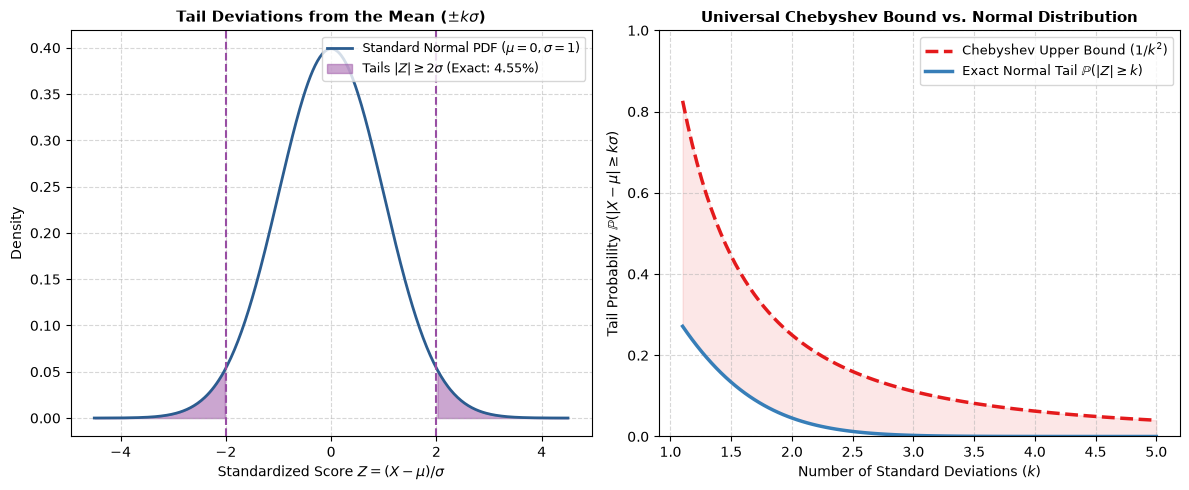

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Standard deviations k to evaluate
k_values = np.linspace(1.1, 5.0, 100)
chebyshev_bound = 1.0 / (k_values**2)

# Exact tail probability P(|X - mu| >= k*sigma) for a Gaussian normal distribution
exact_normal_tail = 2 * (1 - norm.cdf(k_values))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Standard Normal PDF and tails beyond k = 2 standard deviations
z = np.linspace(-4.5, 4.5, 400)
pdf = norm.pdf(z)
k_example = 2.0

ax1.plot(z, pdf, color="#2b5c8f", linewidth=2, label="Standard Normal PDF ($\mu=0, \sigma=1$)")
ax1.fill_between(z[z <= -k_example], pdf[z <= -k_example], color="#984ea3", alpha=0.5, label=f"Tails $|Z| \geq {int(k_example)}\sigma$ (Exact: $4.55\%$)")
ax1.fill_between(z[z >= k_example], pdf[z >= k_example], color="#984ea3", alpha=0.5)
ax1.axvline(-k_example, color="#984ea3", linestyle="--", linewidth=1.5)
ax1.axvline(k_example, color="#984ea3", linestyle="--", linewidth=1.5)
ax1.set_title("Tail Deviations from the Mean ($\pm k\sigma$)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Standardized Score $Z = (X - \mu)/\sigma$", fontsize=10)
ax1.set_ylabel("Density", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=9)

# Plot 2: Chebyshev's Upper Bound vs Exact Normal Distribution Tails
ax2.plot(k_values, chebyshev_bound, color="#e41a1c", linewidth=2.5, linestyle="--", label="Chebyshev Upper Bound ($1/k^2$)")
ax2.plot(k_values, exact_normal_tail, color="#377eb8", linewidth=2.5, label="Exact Normal Tail $\mathbb{P}(|Z| \geq k)$")
ax2.set_title("Universal Chebyshev Bound vs. Normal Distribution", fontsize=11, fontweight="bold")
ax2.set_xlabel("Number of Standard Deviations ($k$)", fontsize=10)
ax2.set_ylabel("Tail Probability $\mathbb{P}(|X - \mu| \geq k\sigma)$", fontsize=10)
ax2.set_ylim(0, 1.0)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9.5)

# Highlight universal coverage
ax2.fill_between(k_values, exact_normal_tail, chebyshev_bound, color="#e41a1c", alpha=0.1, label="Universal Distribution Allowance")

plt.tight_layout()
plt.show()